# Assignment - PY/01

## Assignment Details
- Create a notebook that uses the airquality dataset from `pydataset` and walks students through core pandas skills: structure, head/tail, summary stats, missing values, selection, filtering, sorting, duplicates, derived columns, and groupby/aggregation.

## Practise Exercises
- Inspecting structure: shape, dtypes, info, head, tail
- Summary stats: describe, nunique
- Missing values: isna, fillna (median/mean imputation)
- Selecting columns/rows: lists, iloc, boolean masks, isin
- Filtering with conditions and ranges
- Sorting by multiple columns
- Duplicates: duplicated, drop_duplicates
- Derived columns & categorization: arithmetic, pd.cut
- Groupby & aggregation: agg, boolean-to-int counting
- (Optional) quick sanity plots


## Few Initial Commands to help you load the data

In [1]:
# Install libraries if not available
import pandas as pd
import numpy as np
from pydataset import data

In [2]:
# Option A: Load directly from pydataset
df = data('airquality')

In [3]:
df.shape

(153, 6)

In [4]:
df.head(2)

,Ozone,Solar.R,Wind,Temp,Month,Day
1,41.0,190.0,7.4,67,5,1
2,36.0,118.0,8.0,72,5,2


## Task 1. Inspect the structure
- Show the shape (rows, columns)
- List column names and dtypes
- Display the first 5 and last 5 rows

> Hints: `df.shape`, `df.dtypes`, `df.columns`, `df.head()`, `df.tail()`, `df.info()`

In [5]:
# Shape
print("Shape (rows, columns):", df.shape)

Shape (rows, columns): (153, 6)


In [6]:
# Column names & dtypes
print("Columns:", list(df.columns))
print()
print(df.dtypes)

Columns: ['Ozone', 'Solar.R', 'Wind', 'Temp', 'Month', 'Day']

Ozone      float64
Solar.R    float64
Wind       float64
Temp         int64
Month        int64
Day          int64
dtype: object


In [7]:
# Head and Tail
display(df.head(5))
display(df.tail(5))

,Ozone,Solar.R,Wind,Temp,Month,Day
1,41.0,190.0,7.4,67,5,1
2,36.0,118.0,8.0,72,5,2
3,12.0,149.0,12.6,74,5,3
4,18.0,313.0,11.5,62,5,4
5,NaN,NaN,14.3,56,5,5


,Ozone,Solar.R,Wind,Temp,Month,Day
149,30.0,193.0,6.9,70,9,26
150,NaN,145.0,13.2,77,9,27
151,14.0,191.0,14.3,75,9,28
152,18.0,131.0,8.0,76,9,29
153,20.0,223.0,11.5,68,9,30


In [8]:
# Info Summary
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 153 entries, 1 to 153
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ozone    116 non-null    float64
 1   Solar.R  146 non-null    float64
 2   Wind     153 non-null    float64
 3   Temp     153 non-null    int64  
 4   Month    153 non-null    int64  
 5   Day      153 non-null    int64  
dtypes: float64(3), int64(3)
memory usage: 7.3 KB


## Task 2. Basic summary stats
- Produce descriptive statistics for numeric columns.
- For each column, show number of unique values.

> Hints: `df.describe()`, `df.nunique()`

In [9]:
# code for Task 2
display(df.describe())
print()
print("Unique values per column:")
print(df.nunique())

,Ozone,Solar.R,Wind,Temp,Month,Day
count,116.000000,146.000000,153.000000,153.000000,153.000000,153.000000
mean,42.129310,185.931507,9.957516,77.882353,6.993464,15.803922
std,32.987885,90.058422,3.523001,9.465270,1.416522,8.864520
min,1.000000,7.000000,1.700000,56.000000,5.000000,1.000000
25%,18.000000,115.750000,7.400000,72.000000,6.000000,8.000000
50%,31.500000,205.000000,9.700000,79.000000,7.000000,16.000000
75%,63.250000,258.750000,11.500000,85.000000,8.000000,23.000000
max,168.000000,334.000000,20.700000,97.000000,9.000000,31.000000



Unique values per column:
Ozone       67
Solar.R    117
Wind        31
Temp        40
Month        5
Day         31
dtype: int64


## Task 3. Missing values
- Count missing values per column.
- Create a copy `df_mv` where you impute:
  - `Ozone`: fill with the column median (numeric)
  - `Solar.R`: fill with the column mean (numeric)
- Briefly comment: why might median be preferred over mean in some cases?

> Hints: `df.isna().sum()`, `df.copy()`, `fillna()`

In [10]:
# code for Task 3

# Count missing values per column
print("Missing values per column:")
print(df.isna().sum())

# Create a copy and impute
df_mv = df.copy()
df_mv['Ozone'] = df_mv['Ozone'].fillna(df_mv['Ozone'].median())
df_mv['Solar.R'] = df_mv['Solar.R'].fillna(df_mv['Solar.R'].mean())

print()
print("Missing values after imputation:")
print(df_mv.isna().sum())

Missing values per column:
Ozone      37
Solar.R     7
Wind        0
Temp        0
Month       0
Day         0
dtype: int64

Missing values after imputation:
Ozone      0
Solar.R    0
Wind       0
Temp       0
Month      0
Day        0
dtype: int64


**Why median over mean?** The median is more robust to outliers and skewed distributions. `Ozone` readings can have extreme spikes on high-pollution days, so the mean would be pulled upward by those outliers, while the median better represents a "typical" value. Mean is a reasonable choice for `Solar.R` here because it is less skewed and we simply want a smooth, representative fill value.

## Task 4. Selecting columns & rows
- Select the columns: `Ozone`, `Solar.R`, `Temp` into a new DataFrame `df_sel`.
- Select the first 10 rows of `df_sel`.
- Select rows where `Month` is May (5) or June (6) only.

> Hints: Column lists, `iloc`, boolean masks, `isin`

In [11]:
# code for Task 4

# Select columns into a new DataFrame
df_sel = df[['Ozone', 'Solar.R', 'Temp']]
display(df_sel.head())

# First 10 rows of df_sel
first_10 = df_sel.iloc[:10]
display(first_10)

# Rows where Month is May (5) or June (6) only
may_june = df[df['Month'].isin([5, 6])]
display(may_june.head())
print("May/June rows:", may_june.shape[0])

,Ozone,Solar.R,Temp
1,41.0,190.0,67
2,36.0,118.0,72
3,12.0,149.0,74
4,18.0,313.0,62
5,NaN,NaN,56


,Ozone,Solar.R,Temp
1,41.0,190.0,67
2,36.0,118.0,72
3,12.0,149.0,74
4,18.0,313.0,62
5,NaN,NaN,56
6,28.0,NaN,66
7,23.0,299.0,65
8,19.0,99.0,59
9,8.0,19.0,61
10,NaN,194.0,69


,Ozone,Solar.R,Wind,Temp,Month,Day
1,41.0,190.0,7.4,67,5,1
2,36.0,118.0,8.0,72,5,2
3,12.0,149.0,12.6,74,5,3
4,18.0,313.0,11.5,62,5,4
5,NaN,NaN,14.3,56,5,5


May/June rows: 61


## Task 5. Filtering & conditions
- Filter rows where `Ozone` > 100 and `Temp` >= 85.
- Filter rows where `Solar.R` is missing.
- Filter rows for July (7) with `Ozone` between 50 and 100 (inclusive).

> Hints: Combined boolean conditions with `&`, `|`, parentheses; `between()`

In [12]:
# code for Task 5

# Ozone > 100 and Temp >= 85
high_ozone_hot = df[(df['Ozone'] > 100) & (df['Temp'] >= 85)]
display(high_ozone_hot)

# Solar.R is missing
missing_solar = df[df['Solar.R'].isna()]
display(missing_solar)

# July with Ozone between 50 and 100 (inclusive)
july_ozone_range = df[(df['Month'] == 7) & (df['Ozone'].between(50, 100))]
display(july_ozone_range)

,Ozone,Solar.R,Wind,Temp,Month,Day
86,108.0,223.0,8.0,85,7,25
99,122.0,255.0,4.0,89,8,7
101,110.0,207.0,8.0,90,8,9
121,118.0,225.0,2.3,94,8,29


,Ozone,Solar.R,Wind,Temp,Month,Day
5,NaN,NaN,14.3,56,5,5
6,28.0,NaN,14.9,66,5,6
11,7.0,NaN,6.9,74,5,11
27,NaN,NaN,8.0,57,5,27
96,78.0,NaN,6.9,86,8,4
97,35.0,NaN,7.4,85,8,5
98,66.0,NaN,4.6,87,8,6


,Ozone,Solar.R,Wind,Temp,Month,Day
66,64.0,175.0,4.6,83,7,5
68,77.0,276.0,5.1,88,7,7
69,97.0,267.0,6.3,92,7,8
70,97.0,272.0,5.7,92,7,9
71,85.0,175.0,7.4,89,7,10
79,61.0,285.0,6.3,84,7,18
80,79.0,187.0,5.1,87,7,19
81,63.0,220.0,11.5,85,7,20
85,80.0,294.0,8.6,86,7,24
88,52.0,82.0,12.0,86,7,27


## Task 6. Sorting
- Sort the dataset by `Ozone` descending and `Temp` ascending (multi-column sort).
- Sort the dataset by `Month` then `Day` to get chronological order.

> Hints: `sort_values(by=[...], ascending=[...])`

In [13]:
# code for Task 6

# Sort by Ozone descending and Temp ascending
sorted_ozone_temp = df.sort_values(by=['Ozone', 'Temp'], ascending=[False, True])
display(sorted_ozone_temp.head(10))

# Sort by Month then Day (chronological order)
sorted_chronological = df.sort_values(by=['Month', 'Day'], ascending=[True, True])
display(sorted_chronological.head(10))

,Ozone,Solar.R,Wind,Temp,Month,Day
117,168.0,238.0,3.4,81,8,25
62,135.0,269.0,4.1,84,7,1
99,122.0,255.0,4.0,89,8,7
121,118.0,225.0,2.3,94,8,29
30,115.0,223.0,5.7,79,5,30
101,110.0,207.0,8.0,90,8,9
86,108.0,223.0,8.0,85,7,25
69,97.0,267.0,6.3,92,7,8
70,97.0,272.0,5.7,92,7,9
124,96.0,167.0,6.9,91,9,1


,Ozone,Solar.R,Wind,Temp,Month,Day
1,41.0,190.0,7.4,67,5,1
2,36.0,118.0,8.0,72,5,2
3,12.0,149.0,12.6,74,5,3
4,18.0,313.0,11.5,62,5,4
5,NaN,NaN,14.3,56,5,5
6,28.0,NaN,14.9,66,5,6
7,23.0,299.0,8.6,65,5,7
8,19.0,99.0,13.8,59,5,8
9,8.0,19.0,20.1,61,5,9
10,NaN,194.0,8.6,69,5,10


## Task 7. Duplicates
- Check if there are any fully duplicated rows.
- Intentionally create a few duplicate rows (e.g., duplicate first 3 rows) into `df_dup`.
- Remove duplicates and report how many were removed.

> Hints: `df.duplicated()`, `pd.concat([...])`, `drop_duplicates()`

In [14]:
# code for Task 7

# Check for fully duplicated rows in the original data
print("Duplicated rows in original df:", df.duplicated().sum())

# Intentionally create duplicates
df_dup = pd.concat([df, df.head(3)], ignore_index=True)
print("Shape of df_dup (with intentional duplicates):", df_dup.shape)
print("Duplicated rows in df_dup:", df_dup.duplicated().sum())

# Remove duplicates and report how many were removed
before = df_dup.shape[0]
df_dedup = df_dup.drop_duplicates()
after = df_dedup.shape[0]
print(f"Removed {before - after} duplicate row(s). Shape after dedup: {df_dedup.shape}")

Duplicated rows in original df: 0
Shape of df_dup (with intentional duplicates): (156, 6)
Duplicated rows in df_dup: 3
Removed 3 duplicate row(s). Shape after dedup: (153, 6)


## Task 8. Derived columns
- Create a new column `Temp_C` converting Fahrenheit to Celsius.
- Flag a new boolean column `High_Ozone` where `Ozone` > 100.
- Create a categorical column `Temp_Band` with labels: `Cool (<75F)`, `Warm (75-85F)`, `Hot (>85F)`.

> Hints: vectorized arithmetic, `pd.cut()`

In [15]:
# code for Task 8

df['Temp_C'] = (df['Temp'] - 32) * 5 / 9
df['High_Ozone'] = df['Ozone'] > 100
df['Temp_Band'] = pd.cut(
    df['Temp'],
    bins=[-float('inf'), 75, 85, float('inf')],
    labels=['Cool (<75F)', 'Warm (75-85F)', 'Hot (>85F)'],
    right=False
)

display(df[['Temp', 'Temp_C', 'Ozone', 'High_Ozone', 'Temp_Band']].head(10))

,Temp,Temp_C,Ozone,High_Ozone,Temp_Band
1,67,19.444444,41.0,False,Cool (<75F)
2,72,22.222222,36.0,False,Cool (<75F)
3,74,23.333333,12.0,False,Cool (<75F)
4,62,16.666667,18.0,False,Cool (<75F)
5,56,13.333333,NaN,False,Cool (<75F)
6,66,18.888889,28.0,False,Cool (<75F)
7,65,18.333333,23.0,False,Cool (<75F)
8,59,15.000000,19.0,False,Cool (<75F)
9,61,16.111111,8.0,False,Cool (<75F)
10,69,20.555556,NaN,False,Cool (<75F)


## Task 9. Groupby & aggregation
- Group by `Month` and compute mean Ozone, median Solar.R, and max Temp.
- Within each `Month`, count how many days have `Ozone` > 80.

> Hints: `groupby()`, `agg({...})`, Boolean to int conversion or `np.sum()`

In [16]:
# code for Task 9

# Group by Month: mean Ozone, median Solar.R, max Temp
monthly_summary = df.groupby('Month').agg(
    mean_Ozone=('Ozone', 'mean'),
    median_SolarR=('Solar.R', 'median'),
    max_Temp=('Temp', 'max')
)
display(monthly_summary)

# Within each Month, count how many days have Ozone > 80
df['Ozone_gt_80'] = (df['Ozone'] > 80).astype(int)
days_high_ozone = df.groupby('Month')['Ozone_gt_80'].sum()
print("Days with Ozone > 80 per month:")
print(days_high_ozone)

,mean_Ozone,median_SolarR,max_Temp
Month,,,
5,23.615385,194.0,81
6,29.444444,188.5,93
7,59.115385,253.0,92
8,59.961538,197.5,97
9,31.448276,192.0,93


Days with Ozone > 80 per month:
Month
5    1
6    0
7    6
8    7
9    2
Name: Ozone_gt_80, dtype: int64


### Task 10. (Stretch) Quick sanity plots *(optional)*
If permitted, create two simple charts to visualize patterns:
- Histogram of `Ozone` (after imputation, using `df_mv` if you created it).
- Line plot of `Temp` across days for **August (8)** ordered by Day.

> **Hints:** `matplotlib` basic plotting

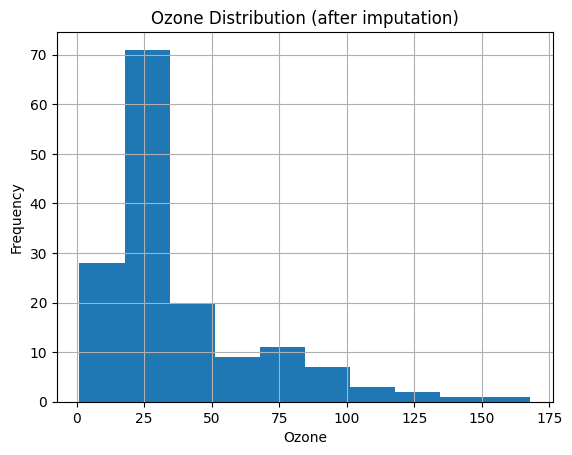

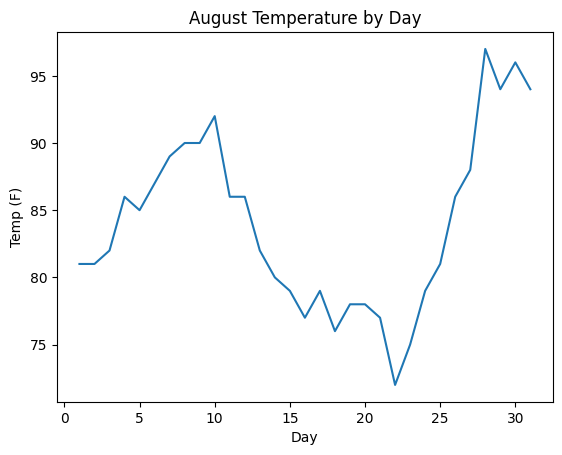

In [17]:
# Your code for Task 10 (optional)
import matplotlib.pyplot as plt

df_mv['Ozone'].hist()
plt.title('Ozone Distribution (after imputation)')
plt.xlabel('Ozone')
plt.ylabel('Frequency')
plt.show()

august = df[df['Month'] == 8].sort_values('Day')
plt.plot(august['Day'], august['Temp'])
plt.title('August Temperature by Day')
plt.xlabel('Day')
plt.ylabel('Temp (F)')
plt.show()

## Insights

1. **Seasonality of Ozone:** Mean ozone levels rise noticeably in the summer months (July-August) compared to May, consistent with higher temperatures and more stagnant air driving ozone formation.
2. **Missingness pattern:** `Ozone` and `Solar.R` are the only columns with missing values, and `Ozone` has noticeably more gaps than `Solar.R` — suggesting the ozone sensor/measurement was more prone to dropouts than the solar radiation sensor.
